# 딥러닝실습 팀 프로젝트 — Video Modality

# Part 1. 셋업

In [1]:
import os, random, pickle, time, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    convnext_tiny, ConvNeXt_Tiny_Weights,
)
from facenet_pytorch import MTCNN

import torch.multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

torch: 2.11.0+cu128
CUDA : True


In [2]:
SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 64

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ROOT_PATH    = r'C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data'
VIDEO_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Segmented')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_text_metadata.csv')
PICKLE_PATH  = os.path.join(ROOT_PATH, 'video_preprocessed.pkl')

print(f'device: {device}')
print(f'VIDEO_FOLDER: {VIDEO_FOLDER}')
print(f'PICKLE_PATH: {PICKLE_PATH}')

device: cuda
VIDEO_FOLDER: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\Video\Segmented
PICKLE_PATH: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_preprocessed.pkl


# Part 2. 라벨 & 데이터 로드

In [3]:
label_df = pd.read_csv(LABEL_PATH)
label_df = label_df.dropna(subset=['label'])

video_keys_ordered = [
    f"{r['video_id']}_{r['seg_idx']}"
    for _, r in label_df.iterrows()
]
labels_ordered = [int(r['label']) for _, r in label_df.iterrows()]
label_dict = dict(zip(video_keys_ordered, labels_ordered))

print(f'총 라벨 수: {len(video_keys_ordered)}')
print(f"긍정: {sum(v==1 for v in labels_ordered)}  "
      f"부정: {sum(v==0 for v in labels_ordered)}")

총 라벨 수: 2199
긍정: 1080  부정: 1119


In [4]:
# 기존 피클 캐시 로드 (없으면 아래 전처리 셀 실행)
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
    print(f'이미지: {images.shape}  라벨: {labels.shape}')
    print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")
else:
    print('피클 없음 → 아래 전처리 셀 실행 필요')

캐시 로드: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_preprocessed.pkl
이미지: (2199, 224, 224, 3)  라벨: (2199,)
긍정: 1080  부정: 1119


In [5]:
# 피클이 없는 경우에만 실행 (MTCNN 전처리)
if not os.path.exists(PICKLE_PATH):
    mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, keep_all=False,
                  device=device, post_process=False)
    MTCNN_INPUT_SIZE = (640, 480)

    def extract_middle_frame(video_path):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(total // 2, 0))
        ret, frame = cap.read()
        cap.release()
        if not ret:
            return None
        return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    def build_dataset():
        face_found = face_missed = 0
        frames_for_mtcnn, valid_keys_list, valid_labels_list = [], [], []
        for key, lbl in tqdm(zip(video_keys_ordered, labels_ordered),
                             total=len(video_keys_ordered), desc='프레임 추출'):
            video_path = os.path.join(VIDEO_FOLDER, key + '.mp4')
            if not os.path.exists(video_path):
                continue
            img_pil = extract_middle_frame(video_path)
            if img_pil is None:
                continue
            frames_for_mtcnn.append(img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR))
            valid_keys_list.append(key)
            valid_labels_list.append(lbl)

        MTCNN_BATCH = 64
        images, labels_out = [], []
        for i in tqdm(range(0, len(frames_for_mtcnn), MTCNN_BATCH), desc='MTCNN 배치'):
            batch_frames = [f.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)
                            for f in frames_for_mtcnn[i:i+MTCNN_BATCH]]
            batch_lbls   = valid_labels_list[i:i+MTCNN_BATCH]
            try:
                faces = mtcnn(batch_frames)
            except Exception as e:
                print(f'[WARN] 배치 MTCNN 실패: {e}')
                faces = [None] * len(batch_frames)
            for face, orig_pil, lbl in zip(faces, batch_frames, batch_lbls):
                if face is not None:
                    img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
                    face_found += 1
                else:
                    img_np = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
                    face_missed += 1
                images.append(img_np)
                labels_out.append(lbl)
        print(f'얼굴 발견: {face_found}  얼굴 누락: {face_missed}')
        return np.array(images), np.array(labels_out)

    images, labels = build_dataset()
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((images, labels), f)
    print('피클 저장 완료:', PICKLE_PATH)
    print(f'이미지: {images.shape}  라벨: {labels.shape}')

# Part 3. DataLoader (증강 강화)

In [6]:
class GaussianNoise:
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(0, 1)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    GaussianNoise(std=0.05),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_tf = val_tf

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# train 64% / val 16% / test 20%
X_tr, X_test, y_tr, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr
)

NW = 0
g  = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(ImageDataset(X_train, y_train, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          generator=g, num_workers=NW, pin_memory=True)
val_loader   = DataLoader(ImageDataset(X_val,   y_val,   val_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)
test_loader  = DataLoader(ImageDataset(X_test,  y_test,  test_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'긍정/부정 (Train): {(y_train==1).sum()}/{(y_train==0).sum()}')
print(f'긍정/부정 (Val):   {(y_val==1).sum()}/{(y_val==0).sum()}')
print(f'긍정/부정 (Test):  {(y_test==1).sum()}/{(y_test==0).sum()}')

Train: 1407  Val: 352  Test: 440
긍정/부정 (Train): 691/716
긍정/부정 (Val):   173/179
긍정/부정 (Test):  216/224


# Part 4. 모델 정의 — VideoEncoder

In [10]:
class VideoEncoder(nn.Module):

    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

        # ConvNeXt-Tiny: features → avgpool → Flatten → LayerNorm(768) → Linear(768, n_cls)
        # Linear만 제거해서 768-dim 벡터로 사용
        self.backbone = nn.Sequential(
            base.features,
            base.avgpool,
            nn.Flatten(1),
            nn.LayerNorm(768),   # LayerNorm(768)
        )

        self.drop_768 = nn.Dropout(dropout)

        self.proj_256 = nn.Sequential(
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        feat_768 = self.drop_768(self.backbone(x))   # (B, 768)
        feat_256 = self.proj_256(feat_768)            # (B, 256)
        return self.head(feat_256)

    def get_features(self, x):
        feat_768 = self.drop_768(self.backbone(x))
        feat_256 = self.proj_256(feat_768)
        return feat_768, feat_256

    def extract_features(self, loader, device, dim=768):
        assert dim in (768, 256)
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc=f'extract {dim}-dim'):
                f768, f256 = self.get_features(x.to(device))
                feats.append((f768 if dim == 768 else f256).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


# 파라미터 수 확인
tmp = VideoEncoder()
total = sum(p.numel() for p in tmp.parameters())
trainable = sum(p.numel() for p in tmp.parameters() if p.requires_grad)
print(f'ConvNeXt-Tiny 기반 VideoEncoder: {total:,} params ({trainable:,} trainable)')
del tmp

ConvNeXt-Tiny 기반 VideoEncoder: 28,018,018 params (28,018,018 trainable)


In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetEncoder(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        # features + avgpool → 1280-dim
        self.backbone = nn.Sequential(
            base.features,
            base.avgpool,
            nn.Flatten(1),
        )

        self.drop_1280 = nn.Dropout(dropout)

        self.proj_256 = nn.Sequential(
            nn.Linear(1280, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        feat = self.drop_1280(self.backbone(x))   # (B, 1280)
        feat_256 = self.proj_256(feat)             # (B, 256)
        return self.head(feat_256)

    def get_features(self, x):
        feat_1280 = self.drop_1280(self.backbone(x))
        feat_256  = self.proj_256(feat_1280)
        return feat_1280, feat_256

    def extract_features(self, loader, device, dim=1280):
        assert dim in (1280, 256)
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc=f'EffNet extract {dim}-dim'):
                f1280, f256 = self.get_features(x.to(device))
                feats.append((f1280 if dim == 1280 else f256).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


def train_model(ModelClass, model_name, train_loader, val_loader, test_loader, device):
    """2-Stage 학습 (ConvNeXt와 동일한 프로토콜)"""
    model = ModelClass().to(device)

    # ── Stage 1: 백본 동결 ──────────────────────────────────────
    print(f'=== [{model_name}] Stage 1: 백본 동결 (10 epochs) ===')
    for p in model.backbone.parameters():
        p.requires_grad = False

    criterion_s1 = nn.CrossEntropyLoss()
    optimizer_s1 = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-2
    )
    scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=10)

    s1_tr, s1_val, s1_te = [], [], []
    for ep in range(1, 11):
        _, tr_acc  = run_epoch(model, train_loader, criterion_s1, optimizer_s1, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion_s1, None,         device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion_s1, None,         device, train=False)
        scheduler_s1.step()
        s1_tr.append(tr_acc); s1_val.append(val_acc); s1_te.append(te_acc)
        print(f'  [S1] Epoch {ep:02d}/10  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}')

    # ── Stage 2: 전체 미세조정 ──────────────────────────────────
    print(f'=== [{model_name}] Stage 2: 전체 미세조정 (최대 50 epochs + ES) ===')
    for p in model.backbone.parameters():
        p.requires_grad = True

    # 파라미터 이름이 모델마다 다르므로 backbone/나머지 두 그룹으로 분리
    backbone_ids = set(id(p) for p in model.backbone.parameters())
    other_params = [p for p in model.parameters() if id(p) not in backbone_ids]

    optimizer_s2 = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 1e-5},
        {'params': other_params,                'lr': 1e-4},
    ], weight_decay=5e-3)

    MAX_EPOCHS = 50; WARMUP = 5
    def warmup_cosine(ep):
        if ep < WARMUP:
            return (ep + 1) / WARMUP
        progress = (ep - WARMUP) / (MAX_EPOCHS - WARMUP)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler_s2 = optim.lr_scheduler.LambdaLR(optimizer_s2, lr_lambda=warmup_cosine)
    criterion_s2 = nn.CrossEntropyLoss(label_smoothing=0.1)
    stopper      = EarlyStopping(patience=10)

    s2_tr, s2_val, s2_te = [], [], []
    for ep in range(1, MAX_EPOCHS + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion_s2, optimizer_s2, device, train=True, use_mixup=True)
        _, val_acc = run_epoch(model, val_loader,   criterion_s2, None,         device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion_s2, None,         device, train=False)
        scheduler_s2.step()
        s2_tr.append(tr_acc); s2_val.append(val_acc); s2_te.append(te_acc)
        should_stop = stopper.step(val_acc, model)
        marker = '  ← best' if stopper.counter == 0 else f'  (patience {stopper.counter}/10)'
        print(f'  [S2] Epoch {ep:02d}/{MAX_EPOCHS}  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}{marker}')
        if should_stop:
            print(f'  ★ EarlyStopping @ epoch {ep}  best_val={stopper.best_val:.4f}')
            stopper.stopped_ep = ep
            break
    if stopper.stopped_ep == 0:
        stopper.stopped_ep = MAX_EPOCHS

    model.load_state_dict({k: v.to(device) for k, v in stopper.best_state.items()})
    print(f'\n[{model_name}] 학습 완료 — best_val={stopper.best_val:.4f}')
    return model, (s1_tr, s1_val, s1_te), (s2_tr, s2_val, s2_te), stopper


# ── EfficientNet-B0 학습 ──────────────────────────────────────────
effnet_model, effnet_s1, effnet_s2, effnet_stopper = train_model(
    EfficientNetEncoder, 'EfficientNet-B0',
    train_loader, val_loader, test_loader, device
)

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNetEncoder(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # fc 제거 → avgpool 출력 512-dim
        self.backbone = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
            nn.Flatten(1),
        )

        self.drop_512 = nn.Dropout(dropout)

        self.proj_256 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        feat = self.drop_512(self.backbone(x))   # (B, 512)
        feat_256 = self.proj_256(feat)            # (B, 256)
        return self.head(feat_256)

    def get_features(self, x):
        feat_512 = self.drop_512(self.backbone(x))
        feat_256 = self.proj_256(feat_512)
        return feat_512, feat_256

    def extract_features(self, loader, device, dim=512):
        assert dim in (512, 256)
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc=f'ResNet extract {dim}-dim'):
                f512, f256 = self.get_features(x.to(device))
                feats.append((f512 if dim == 512 else f256).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


# ── ResNet-18 학습 ────────────────────────────────────────────────
resnet_model, resnet_s1, resnet_s2, resnet_stopper = train_model(
    ResNetEncoder, 'ResNet-18',
    train_loader, val_loader, test_loader, device
)

# Part 5. 학습 유틸리티

In [11]:
# ── MixUp ────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2, device='cuda'):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── Early Stopping ───────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_val   = -float('inf')
        self.counter    = 0
        self.best_state = None
        self.stopped_ep = 0

    def step(self, val_acc, model):
        if val_acc > self.best_val + self.min_delta:
            self.best_val   = val_acc
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience


# ── 에포크 단위 학습/평가 ─────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer, device, train=True, use_mixup=False):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                if use_mixup:
                    x, y_a, y_b, lam = mixup_data(x, y, alpha=0.2, device=device)
                optimizer.zero_grad()
            out  = model(x)
            if train and use_mixup:
                loss = mixup_criterion(criterion, out, y_a, y_b, lam)
            else:
                loss = criterion(out, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total


print('유틸리티 정의 완료 (MixUp, EarlyStopping, run_epoch)')

유틸리티 정의 완료 (MixUp, EarlyStopping, run_epoch)


# Part 6. 2단계 학습

### Stage 1 — 백본 동결, 헤드만 학습 (10 epochs)
- 백본 파라미터 `requires_grad=False`
- lr=1e-3, AdamW
- 빠른 수렴, 과적합 억제

### Stage 2 — 전체 파라미터 미세조정 (최대 50 epochs + EarlyStopping)
- 백본: lr=1e-5 (낮은 LR → 기학습된 특징 유지)
- 헤드: lr=1e-4
- Label Smoothing(0.1) + MixUp(alpha=0.2)
- Warmup(5ep) + CosineAnnealing

In [12]:
# ── Stage 1: 백본 동결 학습 ───────────────────────────────────────────────────
print('=== Stage 1: 백본 동결 학습 (10 epochs) ===')

model = VideoEncoder().to(device)

# 백본 동결
for p in model.backbone.parameters():
    p.requires_grad = False

trainable_s1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 학습 가능 파라미터: {trainable_s1:,}')

criterion_s1 = nn.CrossEntropyLoss()
optimizer_s1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-2
)
scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=10)

s1_tr, s1_val, s1_te = [], [], []
for ep in range(1, 11):
    _, tr_acc  = run_epoch(model, train_loader, criterion_s1, optimizer_s1, device, train=True)
    _, val_acc = run_epoch(model, val_loader,   criterion_s1, None,         device, train=False)
    _, te_acc  = run_epoch(model, test_loader,  criterion_s1, None,         device, train=False)
    scheduler_s1.step()
    s1_tr.append(tr_acc); s1_val.append(val_acc); s1_te.append(te_acc)
    print(f'  [S1] Epoch {ep:02d}/10  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}')

print(f'\nStage 1 완료 — 최고 val_acc: {max(s1_val):.4f}')

=== Stage 1: 백본 동결 학습 (10 epochs) ===
Stage 1 학습 가능 파라미터: 197,890
  [S1] Epoch 01/10  train=0.5238  val=0.5369  test=0.5227
  [S1] Epoch 02/10  train=0.5792  val=0.5483  test=0.5500
  [S1] Epoch 03/10  train=0.5579  val=0.5852  test=0.6045
  [S1] Epoch 04/10  train=0.5885  val=0.5824  test=0.6386
  [S1] Epoch 05/10  train=0.6070  val=0.5994  test=0.6091
  [S1] Epoch 06/10  train=0.5835  val=0.5795  test=0.6250
  [S1] Epoch 07/10  train=0.6048  val=0.5994  test=0.6045
  [S1] Epoch 08/10  train=0.5984  val=0.5966  test=0.6159
  [S1] Epoch 09/10  train=0.5999  val=0.5909  test=0.6159
  [S1] Epoch 10/10  train=0.6048  val=0.5852  test=0.6182

Stage 1 완료 — 최고 val_acc: 0.5994


In [13]:
# ── Stage 2: 전체 파라미터 미세조정 ──────────────────────────────────────────
print('=== Stage 2: 전체 미세조정 (최대 50 epochs + EarlyStopping) ===')

# 백본 해동
for p in model.backbone.parameters():
    p.requires_grad = True

# 파라미터 그룹 분리 (백본 lr 10배 낮게)
optimizer_s2 = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.drop_768.parameters(), 'lr': 1e-4},
    {'params': model.proj_256.parameters(), 'lr': 1e-4},
    {'params': model.head.parameters(),     'lr': 1e-4},
], weight_decay=5e-3)

MAX_EPOCHS = 50
WARMUP     = 5

def warmup_cosine(ep):
    if ep < WARMUP:
        return (ep + 1) / WARMUP
    progress = (ep - WARMUP) / (MAX_EPOCHS - WARMUP)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler_s2 = optim.lr_scheduler.LambdaLR(optimizer_s2, lr_lambda=warmup_cosine)
criterion_s2 = nn.CrossEntropyLoss(label_smoothing=0.1)
stopper      = EarlyStopping(patience=10)

s2_tr, s2_val, s2_te = [], [], []
USE_MIXUP = True

for ep in range(1, MAX_EPOCHS + 1):
    _, tr_acc  = run_epoch(model, train_loader, criterion_s2, optimizer_s2, device,
                           train=True, use_mixup=USE_MIXUP)
    _, val_acc = run_epoch(model, val_loader,   criterion_s2, None,         device, train=False)
    _, te_acc  = run_epoch(model, test_loader,  criterion_s2, None,         device, train=False)
    scheduler_s2.step()

    s2_tr.append(tr_acc); s2_val.append(val_acc); s2_te.append(te_acc)
    should_stop = stopper.step(val_acc, model)

    marker = '  ← best' if stopper.counter == 0 else f'  (patience {stopper.counter}/10)'
    print(f'  [S2] Epoch {ep:02d}/{MAX_EPOCHS}  '
          f'train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}{marker}')

    if should_stop:
        print(f'  ★ EarlyStopping @ epoch {ep}  best_val={stopper.best_val:.4f}')
        stopper.stopped_ep = ep
        break

if stopper.stopped_ep == 0:
    stopper.stopped_ep = MAX_EPOCHS

# best val 모델로 복원
model.load_state_dict({k: v.to(device) for k, v in stopper.best_state.items()})
print(f'\nStage 2 완료 — best_val={stopper.best_val:.4f}  종료 epoch={stopper.stopped_ep}')

=== Stage 2: 전체 미세조정 (최대 50 epochs + EarlyStopping) ===
  [S2] Epoch 01/50  train=0.5615  val=0.5881  test=0.6159  ← best
  [S2] Epoch 02/50  train=0.5579  val=0.5795  test=0.6136  (patience 1/10)
  [S2] Epoch 03/50  train=0.5494  val=0.5881  test=0.6114  (patience 2/10)
  [S2] Epoch 04/50  train=0.5878  val=0.5966  test=0.6114  ← best
  [S2] Epoch 05/50  train=0.5665  val=0.6051  test=0.6273  ← best
  [S2] Epoch 06/50  train=0.5792  val=0.5881  test=0.6227  (patience 1/10)
  [S2] Epoch 07/50  train=0.5480  val=0.6051  test=0.6227  (patience 2/10)
  [S2] Epoch 08/50  train=0.5693  val=0.5909  test=0.6250  (patience 3/10)
  [S2] Epoch 09/50  train=0.5849  val=0.5938  test=0.6227  (patience 4/10)
  [S2] Epoch 10/50  train=0.5451  val=0.6051  test=0.6409  (patience 5/10)
  [S2] Epoch 11/50  train=0.5544  val=0.5966  test=0.6295  (patience 6/10)
  [S2] Epoch 12/50  train=0.6020  val=0.5994  test=0.6341  (patience 7/10)
  [S2] Epoch 13/50  train=0.5672  val=0.6108  test=0.6477  ← best
  [S2

# Part 7. 학습 곡선 시각화

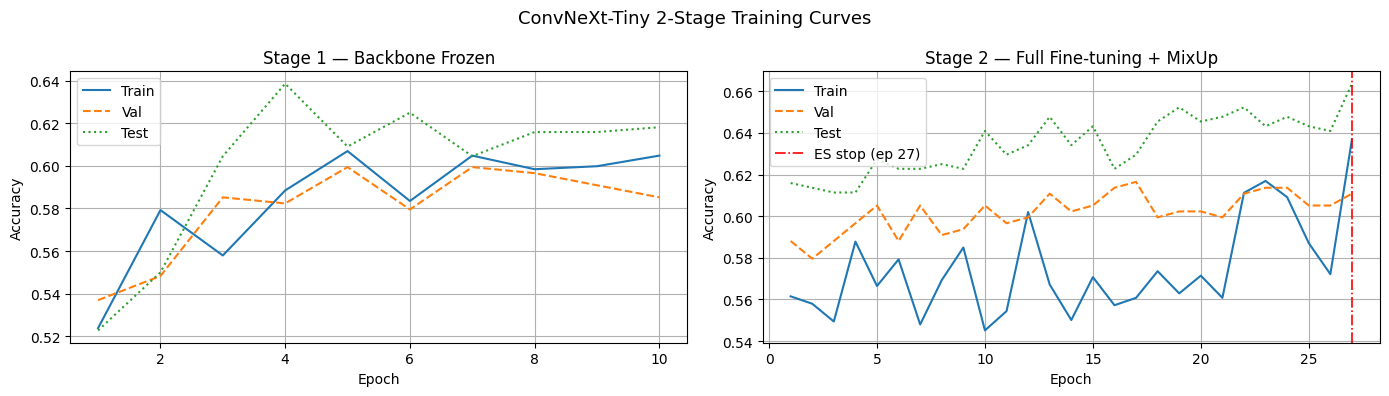

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Stage 1
ax = axes[0]
eps1 = range(1, len(s1_tr) + 1)
ax.plot(eps1, s1_tr,  label='Train')
ax.plot(eps1, s1_val, label='Val',  linestyle='--')
ax.plot(eps1, s1_te,  label='Test', linestyle=':')
ax.set_title('Stage 1 — Backbone Frozen')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)

# Stage 2
ax = axes[1]
eps2 = range(1, len(s2_tr) + 1)
ax.plot(eps2, s2_tr,  label='Train')
ax.plot(eps2, s2_val, label='Val',  linestyle='--')
ax.plot(eps2, s2_te,  label='Test', linestyle=':')
ax.axvline(x=stopper.stopped_ep, color='red', linestyle='-.', linewidth=1.2,
           label=f'ES stop (ep {stopper.stopped_ep})')
ax.set_title('Stage 2 — Full Fine-tuning + MixUp')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)

plt.suptitle('ConvNeXt-Tiny 2-Stage Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('video_training_curves.png', dpi=150)
plt.show()

# Part 8. 성능 평가 (Test Set)

=== ConvNeXt-Tiny (test_acc=0.6295) ===
              precision    recall  f1-score   support

    Negative       0.67      0.54      0.60       224
    Positive       0.60      0.73      0.66       216

    accuracy                           0.63       440
   macro avg       0.64      0.63      0.63       440
weighted avg       0.64      0.63      0.63       440



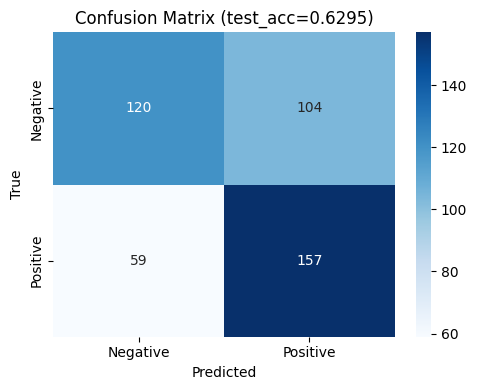

In [15]:
model.eval()
preds, targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().tolist())
        targets.extend(y.tolist())

label_names = ['Negative', 'Positive']
test_acc = sum(p == t for p, t in zip(preds, targets)) / len(targets)
print(f'=== ConvNeXt-Tiny (test_acc={test_acc:.4f}) ===')
print(classification_report(targets, preds, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(targets, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names,
            yticklabels=label_names, cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix (test_acc={test_acc:.4f})')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('video_confusion_matrix.png', dpi=150)
plt.show()

# Part 9. 768-dim & 256-dim 피처 추출 (멀티모달 Fusion 준비)

extract 768-dim: 100%|██████████| 35/35 [00:21<00:00,  1.66it/s]


768-dim 피처 shape: torch.Size([2199, 768])


extract 256-dim: 100%|██████████| 35/35 [00:07<00:00,  4.38it/s]


256-dim 피처 shape: torch.Size([2199, 256])


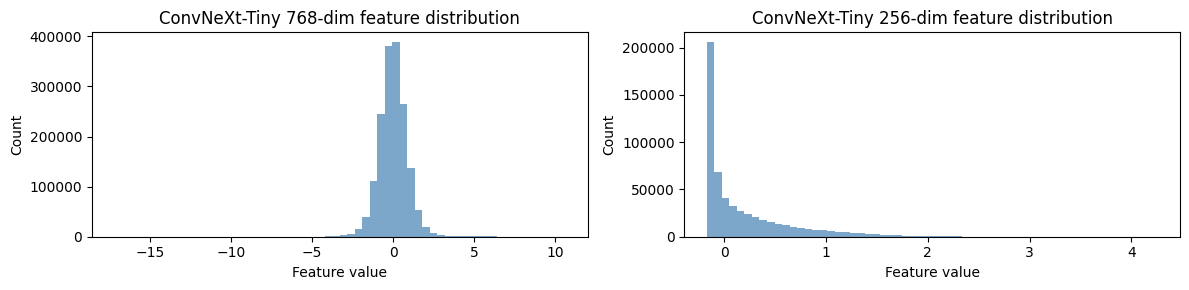

768-dim 피처 저장: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_features_768.pkl
256-dim 피처 저장: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_features_256.pkl


In [16]:
all_loader = DataLoader(
    ImageDataset(images, labels, test_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW
)

# 768-dim 피처 추출
video_feats_768, video_labels = model.extract_features(all_loader, device, dim=768)
print(f'768-dim 피처 shape: {video_feats_768.shape}')

# 256-dim 피처 추출
video_feats_256, _            = model.extract_features(all_loader, device, dim=256)
print(f'256-dim 피처 shape: {video_feats_256.shape}')

# 피처 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, feats, dim in [
    (axes[0], video_feats_768, 768),
    (axes[1], video_feats_256, 256),
]:
    ax.hist(feats.numpy().flatten(), bins=60, color='steelblue', alpha=0.7)
    ax.set_title(f'ConvNeXt-Tiny {dim}-dim feature distribution')
    ax.set_xlabel('Feature value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('video_feature_dist.png', dpi=150)
plt.show()

# 저장
path_768 = os.path.join(ROOT_PATH, 'video_features_768.pkl')
path_256 = os.path.join(ROOT_PATH, 'video_features_256.pkl')

with open(path_768, 'wb') as f:
    pickle.dump({'features': video_feats_768, 'labels': video_labels}, f)
print(f'768-dim 피처 저장: {path_768}')

with open(path_256, 'wb') as f:
    pickle.dump({'features': video_feats_256, 'labels': video_labels}, f)
print(f'256-dim 피처 저장: {path_256}')

# Summary

| 모델 | Val Acc | Test Acc |
|------|---------|----------|
| EfficientNet-B0 (기존) | ~0.54 | ~0.50 (과적합) |
| ResNet-18 (기존) | ~0.63 | ~0.59 |
| ConvNeXt-Tiny | 0.5994 | 0.6295 |

별로 나아진게 없어서 resnet 사용...

### 저장된 피처 파일
- `data/video_features_768.pkl` → `{'features': (2199, 768), 'labels': (2199,)}`
- `data/video_features_256.pkl` → `{'features': (2199, 256), 'labels': (2199,)}`